# 03 — Exploratory Data Analysis (EDA)

## Objective
Understand which factors most strongly predict driver arrival
time (ETA) for Bangalore ride assignments.

## Business Questions We Answer
1. How does ETA relate to road distance? (the obvious baseline)
2. How much does traffic multiplier change ETA beyond distance alone?
3. Does the road-to-straight ratio (route complexity) matter?
4. How does ETA vary by hour of day and day of week?
5. Does weather meaningfully slow drivers down?
6. Does driver speed factor (fast vs cautious drivers) matter?
7. Does driver familiarity with the area reduce ETA?
8. Does pickup pin accuracy affect ETA?
9. Which Bangalore zone pairs have the worst ETAs?
10. How accurate is the app's own ETA estimate vs reality?

## Key EDA Mindset for Regression
We are looking for features that, when they increase or
decrease, cause actual_arrival_time_min to increase or
decrease in a predictable way. Strong relationships here
become strong model features later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["axes.titleweight"]  = "bold"

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

assignments_df = pd.read_csv(
    PATH + "assignments_clean.csv",
    parse_dates=["assignment_timestamp"]
)

print(f"Cleaned assignments loaded ✅")
print(f"  Shape: {assignments_df.shape}")
print(f"\nTarget variable stats:")
print(assignments_df["actual_arrival_time_min"].describe().round(2))

Cleaned assignments loaded ✅
  Shape: (60000, 34)

Target variable stats:
count   57685.000
mean       16.720
std        19.150
min         1.000
25%         2.300
50%         7.100
75%        25.600
max        60.000
Name: actual_arrival_time_min, dtype: float64


## Section 1 — The Baseline Relationship: Distance vs ETA

### Question: How strongly does road distance alone predict ETA?

This is the most fundamental relationship in the entire dataset.
If distance alone explained ETA perfectly, every other feature
would be unnecessary. The gap between "distance alone" and
"actual ETA" is exactly what traffic, weather, and driver
behavior explain.

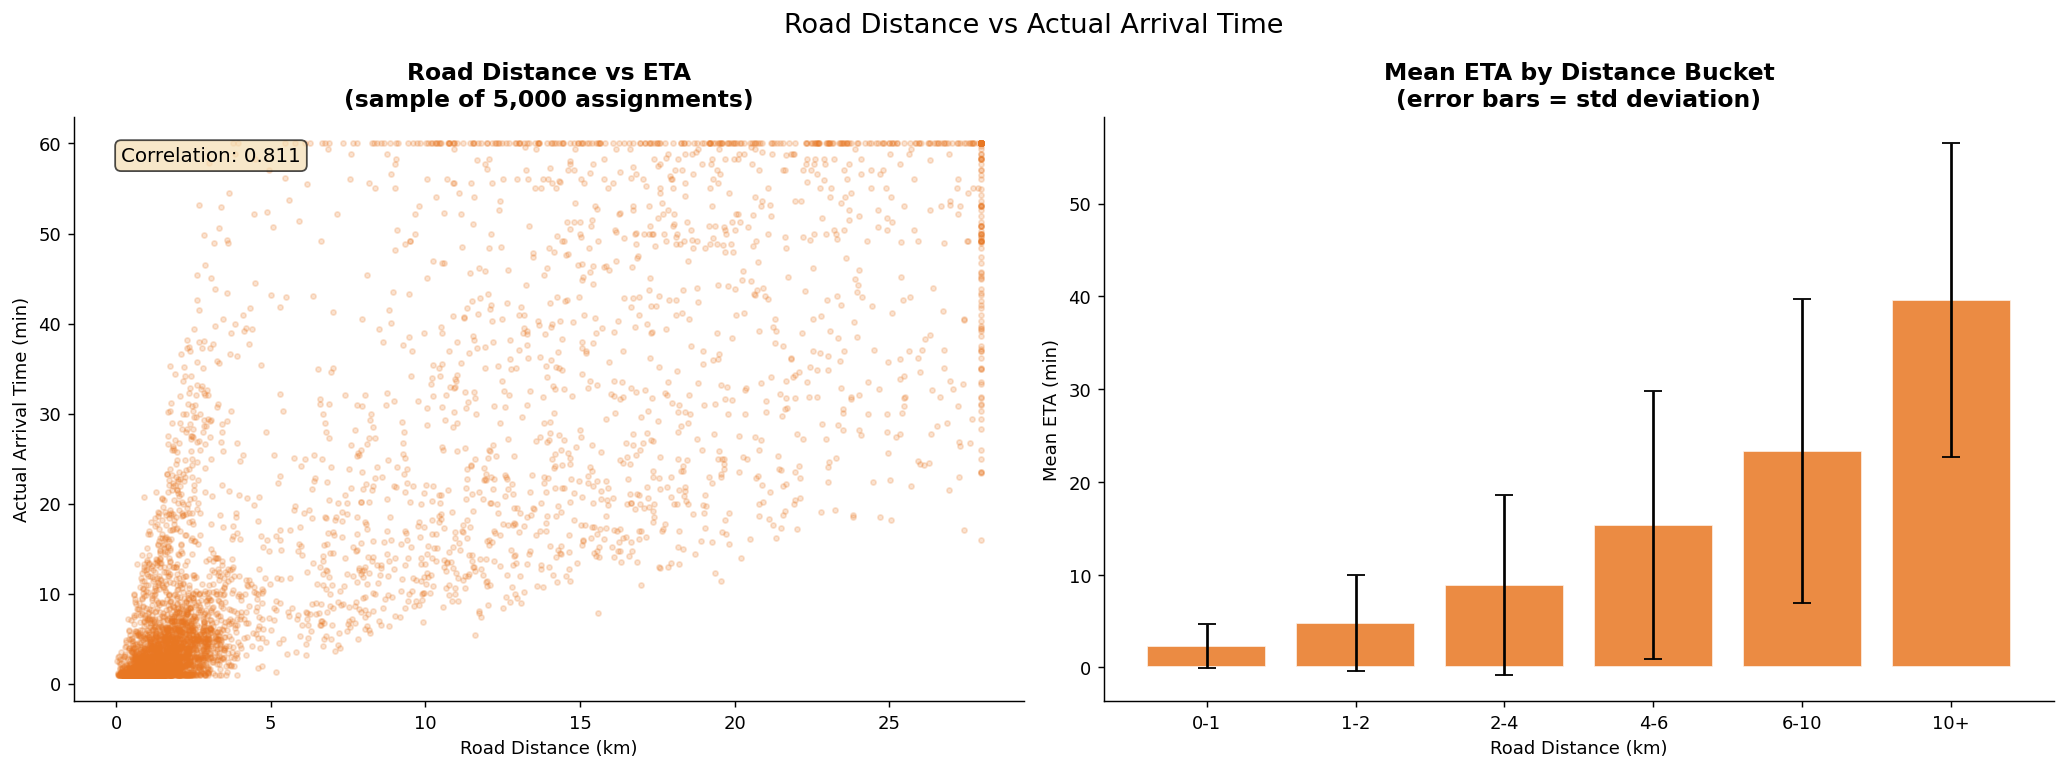

Correlation between road_distance_km and ETA: 0.8109

Mean ETA by distance bucket:
                  mean    std  count
distance_bucket                     
0-1              2.320  2.330   9114
1-2              4.790  5.180  14854
2-4              8.910  9.680  11836
4-6             15.370 14.450   1685
6-10            23.340 16.420   3620
10+             39.570 16.900  16576


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Road Distance vs Actual Arrival Time", fontsize=15)

sample = assignments_df.sample(5000, random_state=42)

axes[0].scatter(
    sample["road_distance_km"],
    sample["actual_arrival_time_min"],
    alpha=0.2, color="#E87722", s=8
)
axes[0].set_title("Road Distance vs ETA\n(sample of 5,000 assignments)")
axes[0].set_xlabel("Road Distance (km)")
axes[0].set_ylabel("Actual Arrival Time (min)")

# Correlation
corr = assignments_df["road_distance_km"].corr(
    assignments_df["actual_arrival_time_min"]
)
axes[0].text(
    0.05, 0.95, f"Correlation: {corr:.3f}",
    transform=axes[0].transAxes, fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7)
)

# Distance bucket vs mean ETA
assignments_df["distance_bucket"] = pd.cut(
    assignments_df["road_distance_km"],
    bins=[0, 1, 2, 4, 6, 10, 50],
    labels=["0-1", "1-2", "2-4", "4-6", "6-10", "10+"]
)
bucket_eta = assignments_df.groupby(
    "distance_bucket", observed=True
)["actual_arrival_time_min"].agg(["mean", "std", "count"])

axes[1].bar(
    bucket_eta.index.astype(str), bucket_eta["mean"],
    yerr=bucket_eta["std"], color="#E87722",
    edgecolor="white", alpha=0.85, capsize=5
)
axes[1].set_title("Mean ETA by Distance Bucket\n(error bars = std deviation)")
axes[1].set_xlabel("Road Distance (km)")
axes[1].set_ylabel("Mean ETA (min)")

plt.tight_layout()
plt.savefig("../data/processed/eda_01_distance_vs_eta.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlation between road_distance_km and ETA: {corr:.4f}")
print("\nMean ETA by distance bucket:")
print(bucket_eta.round(2))

## Section 2 — Traffic Multiplier Impact

### Question: How much does traffic alone change ETA,
### holding distance roughly constant?

If we look only at rides with similar distance but
different traffic conditions, the ETA difference tells us
exactly how powerful traffic is as a standalone signal.

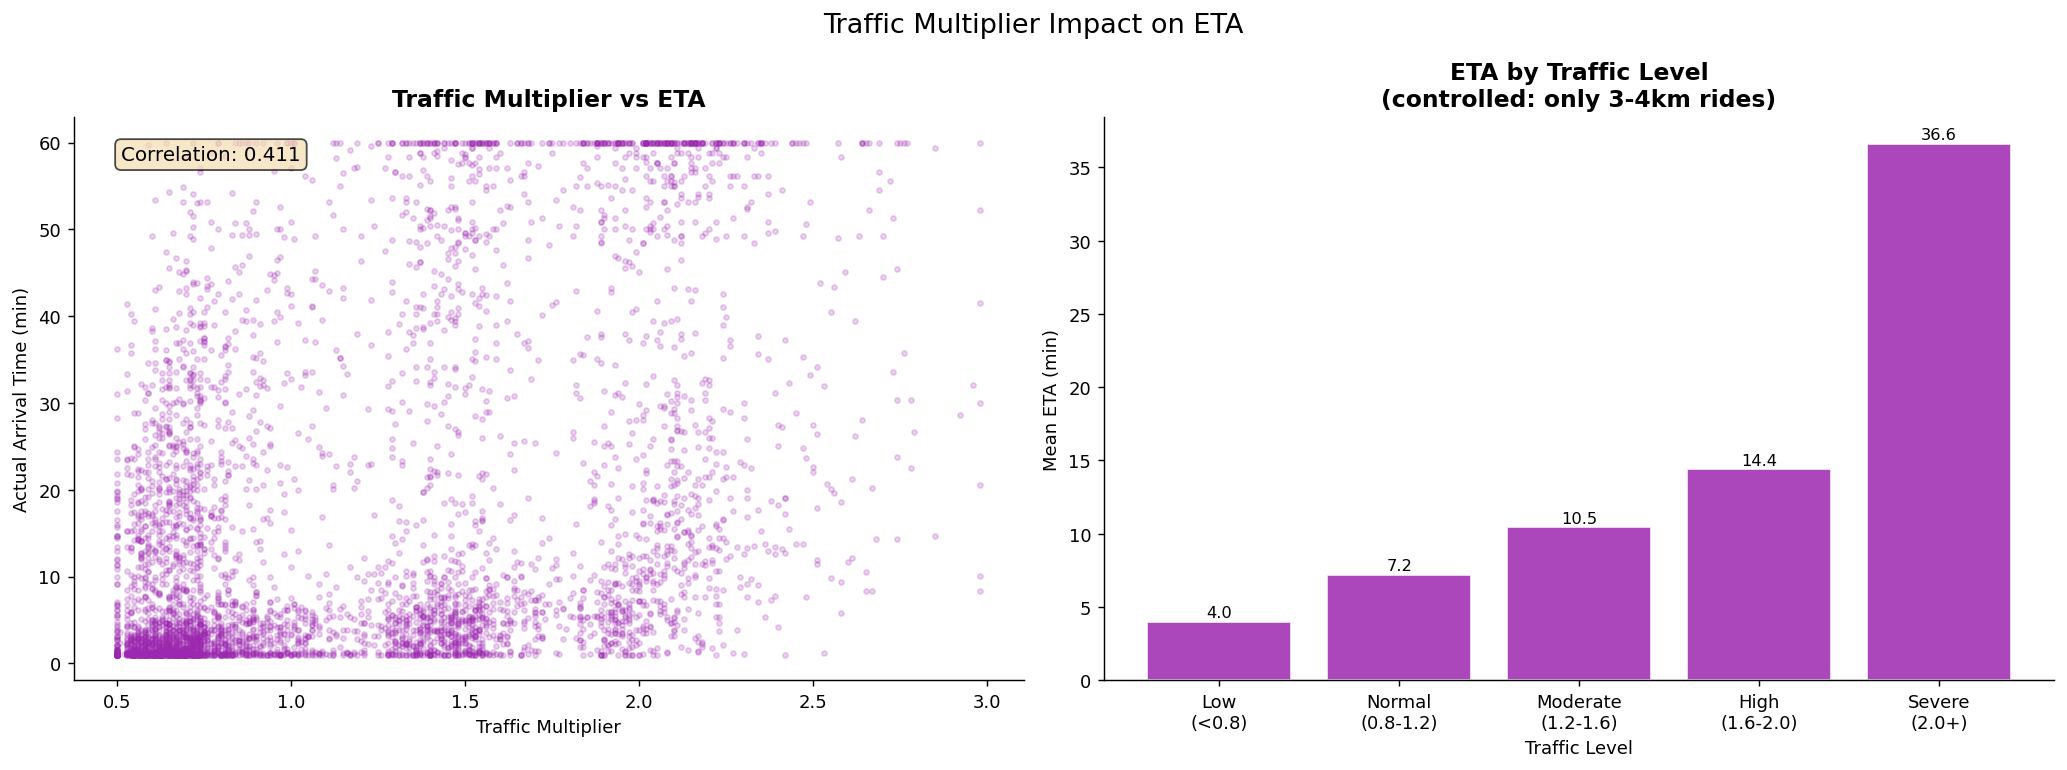

Traffic multiplier correlation with ETA: 0.4111

Controlled comparison (3-4km rides only):
traffic_bucket
Low\n(<0.8)            4.010
Normal\n(0.8-1.2)      7.190
Moderate\n(1.2-1.6)   10.460
High\n(1.6-2.0)       14.410
Severe\n(2.0+)        36.610
Name: actual_arrival_time_min, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Traffic Multiplier Impact on ETA", fontsize=15)

# Traffic multiplier vs ETA scatter
axes[0].scatter(
    sample["traffic_multiplier"],
    sample["actual_arrival_time_min"],
    alpha=0.2, color="#9C27B0", s=8
)
axes[0].set_title("Traffic Multiplier vs ETA")
axes[0].set_xlabel("Traffic Multiplier")
axes[0].set_ylabel("Actual Arrival Time (min)")

traffic_corr = assignments_df["traffic_multiplier"].corr(
    assignments_df["actual_arrival_time_min"]
)
axes[0].text(
    0.05, 0.95, f"Correlation: {traffic_corr:.3f}",
    transform=axes[0].transAxes, fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7)
)

# Controlled comparison: similar distance, different traffic
similar_distance = assignments_df[
    (assignments_df["road_distance_km"] >= 3) &
    (assignments_df["road_distance_km"] <= 4)
].copy()

similar_distance["traffic_bucket"] = pd.cut(
    similar_distance["traffic_multiplier"],
    bins=[0, 0.8, 1.2, 1.6, 2.0, 5],
    labels=["Low\n(<0.8)", "Normal\n(0.8-1.2)",
            "Moderate\n(1.2-1.6)", "High\n(1.6-2.0)", "Severe\n(2.0+)"]
)

traffic_bucket_eta = similar_distance.groupby(
    "traffic_bucket", observed=True
)["actual_arrival_time_min"].mean()

axes[1].bar(
    traffic_bucket_eta.index.astype(str),
    traffic_bucket_eta.values,
    color="#9C27B0", edgecolor="white", alpha=0.85
)
axes[1].set_title("ETA by Traffic Level\n(controlled: only 3-4km rides)")
axes[1].set_xlabel("Traffic Level")
axes[1].set_ylabel("Mean ETA (min)")
for i, v in enumerate(traffic_bucket_eta.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_02_traffic_impact.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Traffic multiplier correlation with ETA: {traffic_corr:.4f}")
print(f"\nControlled comparison (3-4km rides only):")
print(traffic_bucket_eta.round(2))

## Section 3 — Route Complexity (Road-to-Straight Ratio)

### Question: Does the "windiness" of a route matter beyond
### raw distance and traffic?

A route with a ratio of 1.1 is nearly a straight line
(like a highway). A route with a ratio of 1.6 winds through
dense streets, traffic signals, and one-way roads. Two routes
with the SAME straight-line distance can have very different
actual ETAs because of this.

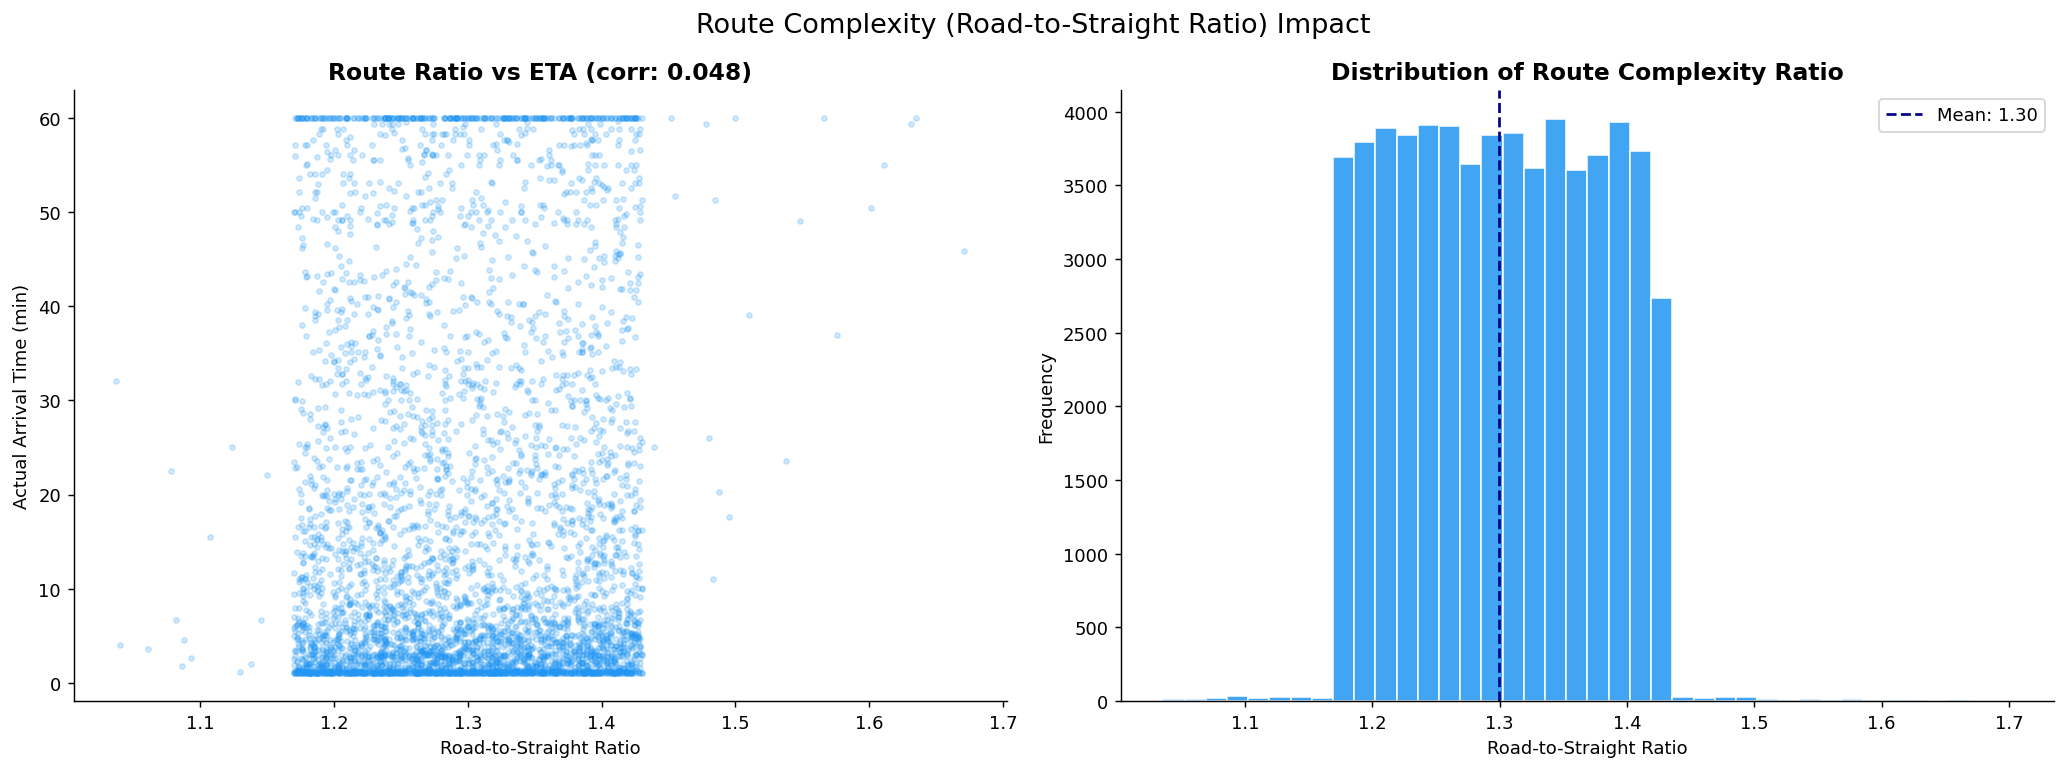

Road-to-straight ratio correlation with ETA: 0.0483
count   60000.000
mean        1.300
std         0.077
min         1.036
25%         1.234
50%         1.300
75%         1.365
max         1.702
Name: road_to_straight_ratio, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Route Complexity (Road-to-Straight Ratio) Impact", fontsize=15)

ratio_corr = assignments_df["road_to_straight_ratio"].corr(
    assignments_df["actual_arrival_time_min"]
)

axes[0].scatter(
    sample["road_to_straight_ratio"],
    sample["actual_arrival_time_min"],
    alpha=0.2, color="#2196F3", s=8
)
axes[0].set_title(f"Route Ratio vs ETA (corr: {ratio_corr:.3f})")
axes[0].set_xlabel("Road-to-Straight Ratio")
axes[0].set_ylabel("Actual Arrival Time (min)")

# Ratio distribution
axes[1].hist(
    assignments_df["road_to_straight_ratio"].dropna(),
    bins=40, color="#2196F3", edgecolor="white", alpha=0.85
)
axes[1].axvline(
    assignments_df["road_to_straight_ratio"].mean(),
    color="navy", linestyle="--",
    label=f"Mean: {assignments_df['road_to_straight_ratio'].mean():.2f}"
)
axes[1].set_title("Distribution of Route Complexity Ratio")
axes[1].set_xlabel("Road-to-Straight Ratio")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_03_route_complexity.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Road-to-straight ratio correlation with ETA: {ratio_corr:.4f}")
print(assignments_df["road_to_straight_ratio"].describe().round(3))

## Section 4 — Time Patterns

### Question: How does ETA vary by hour of day and day of week?

We expect a similar double-peak pattern to what we saw
in surge pricing — morning and evening office rush hours
should show longer ETAs due to traffic congestion.

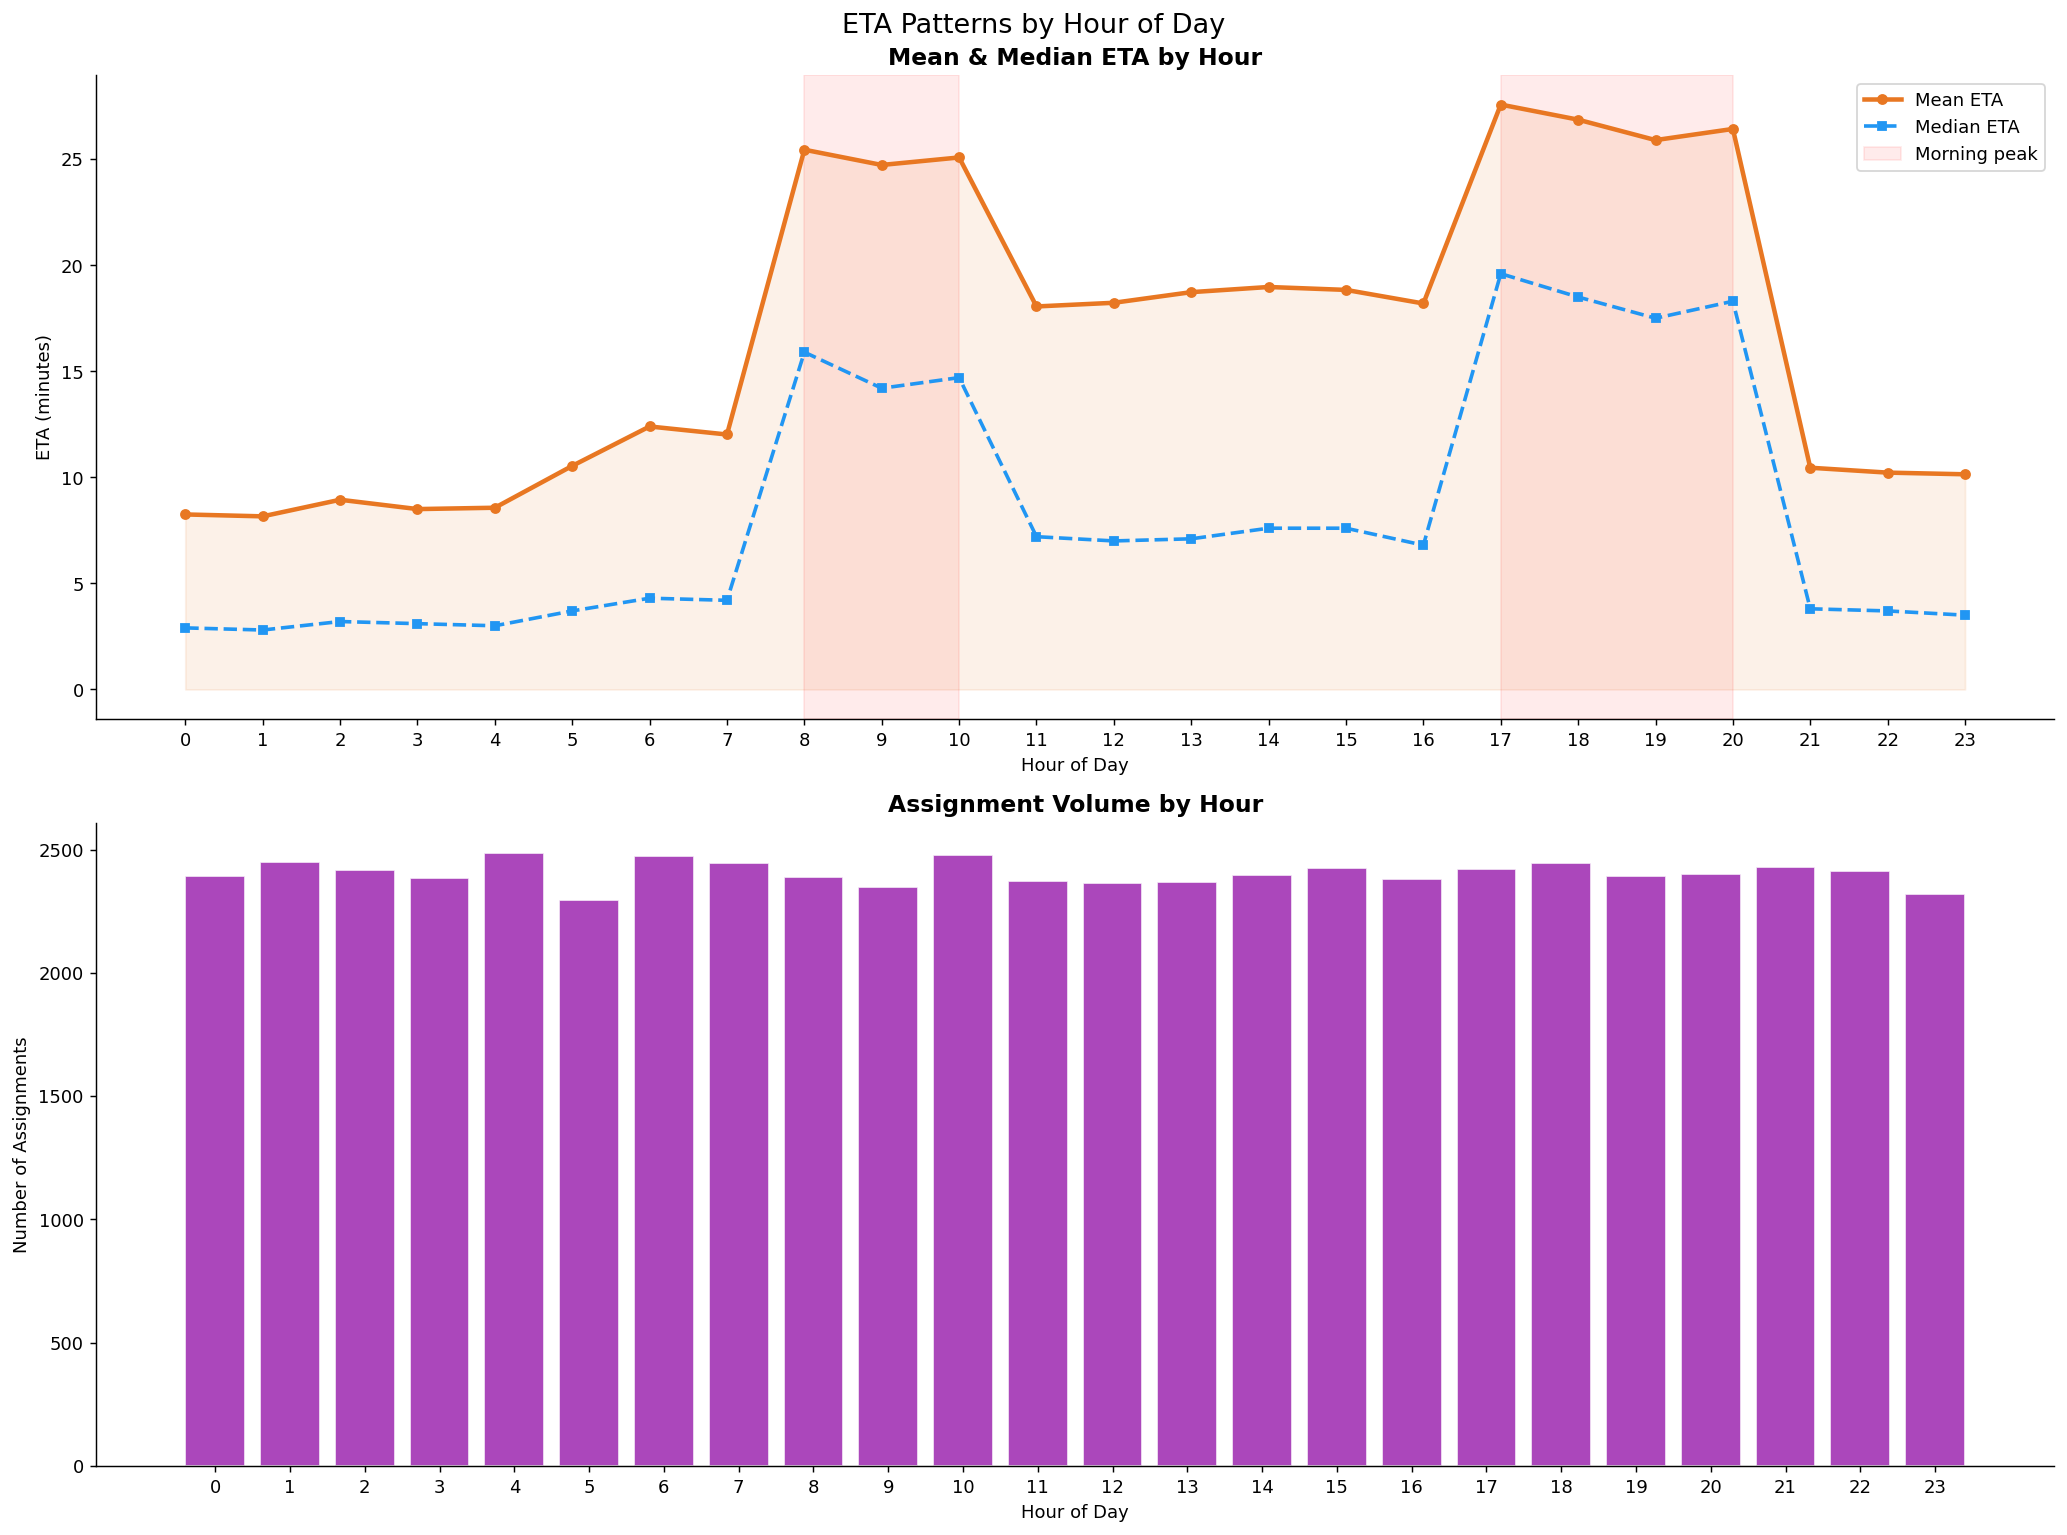

Top 5 highest mean ETA hours:
 hour   mean  median  count
   17 27.574  19.600   2421
   18 26.862  18.500   2445
   20 26.425  18.300   2400
   19 25.898  17.500   2394
    8 25.446  15.900   2387


In [6]:
hourly_eta = assignments_df.groupby("hour")["actual_arrival_time_min"].agg(
    ["mean", "median", "count"]
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle("ETA Patterns by Hour of Day", fontsize=15)

axes[0].plot(
    hourly_eta["hour"], hourly_eta["mean"],
    color="#E87722", linewidth=2.5, marker="o", markersize=5,
    label="Mean ETA"
)
axes[0].plot(
    hourly_eta["hour"], hourly_eta["median"],
    color="#2196F3", linewidth=2, linestyle="--",
    marker="s", markersize=4, label="Median ETA"
)
axes[0].fill_between(
    hourly_eta["hour"], hourly_eta["mean"], alpha=0.1, color="#E87722"
)
axes[0].axvspan(8, 10, alpha=0.08, color="red", label="Morning peak")
axes[0].axvspan(17, 20, alpha=0.08, color="red")
axes[0].set_title("Mean & Median ETA by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("ETA (minutes)")
axes[0].set_xticks(range(0, 24))
axes[0].legend()

axes[1].bar(
    hourly_eta["hour"], hourly_eta["count"],
    color="#9C27B0", edgecolor="white", alpha=0.85
)
axes[1].set_title("Assignment Volume by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Number of Assignments")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig("../data/processed/eda_04_hourly_eta.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 highest mean ETA hours:")
print(hourly_eta.sort_values("mean", ascending=False).head().to_string(index=False))

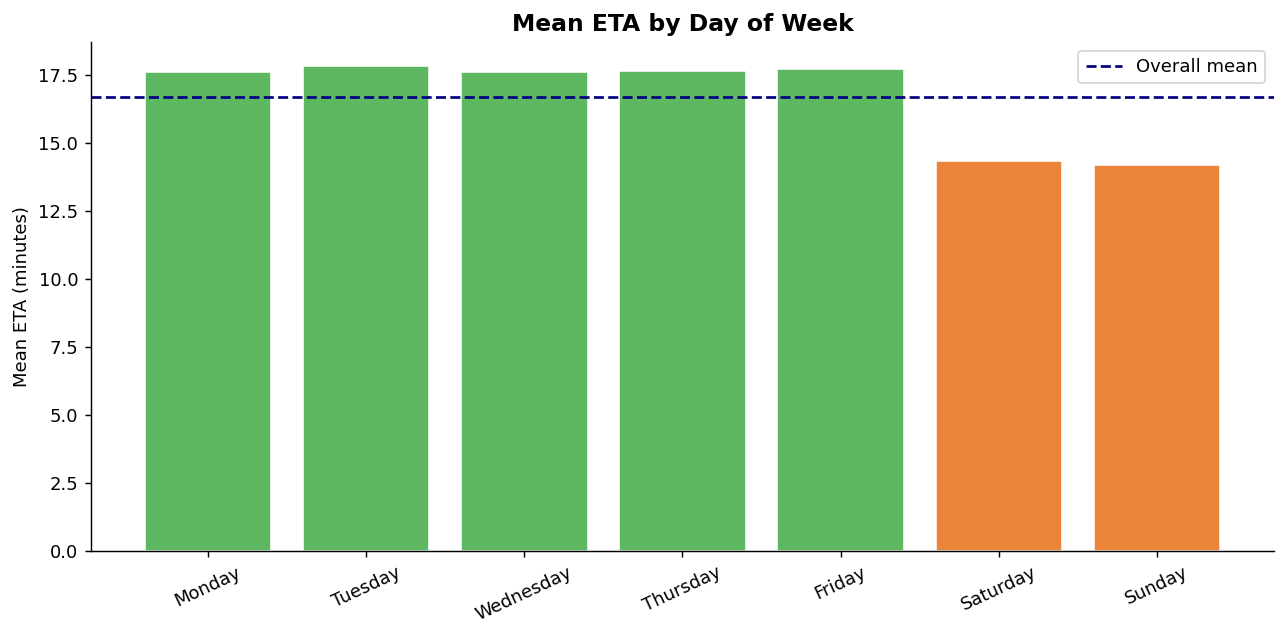

day_of_week
Monday      17.620
Tuesday     17.830
Wednesday   17.630
Thursday    17.670
Friday      17.710
Saturday    14.330
Sunday      14.190
Name: actual_arrival_time_min, dtype: float64


In [7]:
day_order = ["Monday","Tuesday","Wednesday","Thursday",
             "Friday","Saturday","Sunday"]

daily_eta = assignments_df.groupby("day_of_week")[
    "actual_arrival_time_min"
].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4CAF50" if d not in ["Saturday","Sunday"] else "#E87722"
          for d in day_order]
ax.bar(day_order, daily_eta.values, color=colors, edgecolor="white", alpha=0.9)
ax.axhline(assignments_df["actual_arrival_time_min"].mean(),
           color="navy", linestyle="--", label="Overall mean")
ax.set_title("Mean ETA by Day of Week", fontsize=13)
ax.set_ylabel("Mean ETA (minutes)")
ax.tick_params(axis="x", rotation=25)
ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_05_day_of_week.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(daily_eta.round(2))

## Section 5 — Weather Impact on ETA

### Question: Does rain meaningfully slow drivers down in Bangalore?

Our data generator built in rain-based speed reductions.
This section verifies that signal came through clearly
and quantifies exactly how much rain costs in minutes.

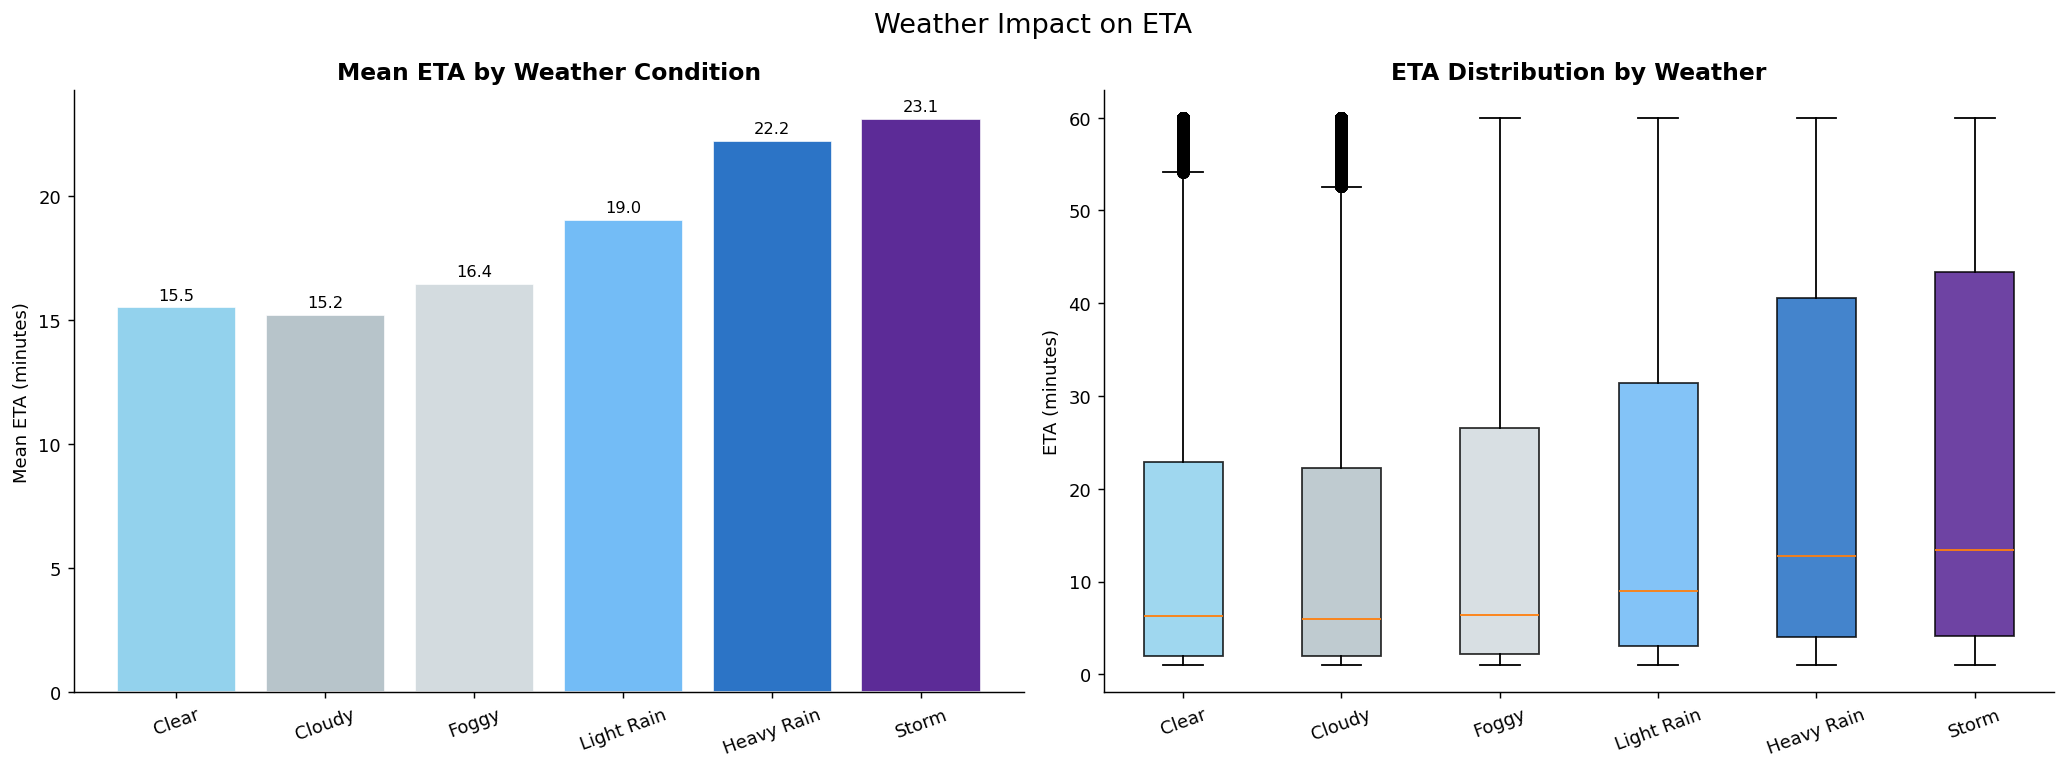

Weather impact on ETA:
                    mean  median  count
weather_condition                      
Clear             15.520   6.300  24835
Cloudy            15.200   6.000  15840
Foggy             16.450   6.400   2737
Light Rain        19.030   9.000   8000
Heavy Rain        22.210  12.800   4581
Storm             23.090  13.400   1692

Storm vs Clear difference: 7.57 minutes (48.8% increase)


In [8]:
weather_order = ["Clear","Cloudy","Foggy","Light Rain","Heavy Rain","Storm"]

weather_eta = assignments_df.groupby("weather_condition")[
    "actual_arrival_time_min"
].agg(["mean", "median", "count"]).reindex(weather_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Weather Impact on ETA", fontsize=15)

colors_weather = ["#87CEEB","#B0BEC5","#CFD8DC","#64B5F6","#1565C0","#4A148C"]

axes[0].bar(
    weather_eta.index, weather_eta["mean"],
    color=colors_weather, edgecolor="white", alpha=0.9
)
axes[0].set_title("Mean ETA by Weather Condition")
axes[0].set_ylabel("Mean ETA (minutes)")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(weather_eta["mean"]):
    axes[0].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

# Boxplot
weather_data = [
    assignments_df[
        assignments_df["weather_condition"]==w
    ]["actual_arrival_time_min"].dropna()
    for w in weather_order
]
bp = axes[1].boxplot(weather_data, patch_artist=True, labels=weather_order)
for patch, color in zip(bp["boxes"], colors_weather):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title("ETA Distribution by Weather")
axes[1].set_ylabel("ETA (minutes)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../data/processed/eda_06_weather_eta.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Weather impact on ETA:")
print(weather_eta.round(2))

clear_mean = weather_eta.loc["Clear", "mean"]
storm_mean = weather_eta.loc["Storm", "mean"]
print(f"\nStorm vs Clear difference: {storm_mean - clear_mean:.2f} minutes "
      f"({((storm_mean/clear_mean)-1)*100:.1f}% increase)")

## Section 6 — Driver-Side Factors

### Question: Do faster/more familiar drivers actually
### produce shorter ETAs in the data?

This tests whether our driver behavior simulation
(speed_factor, familiarity_score) created a real,
detectable signal.

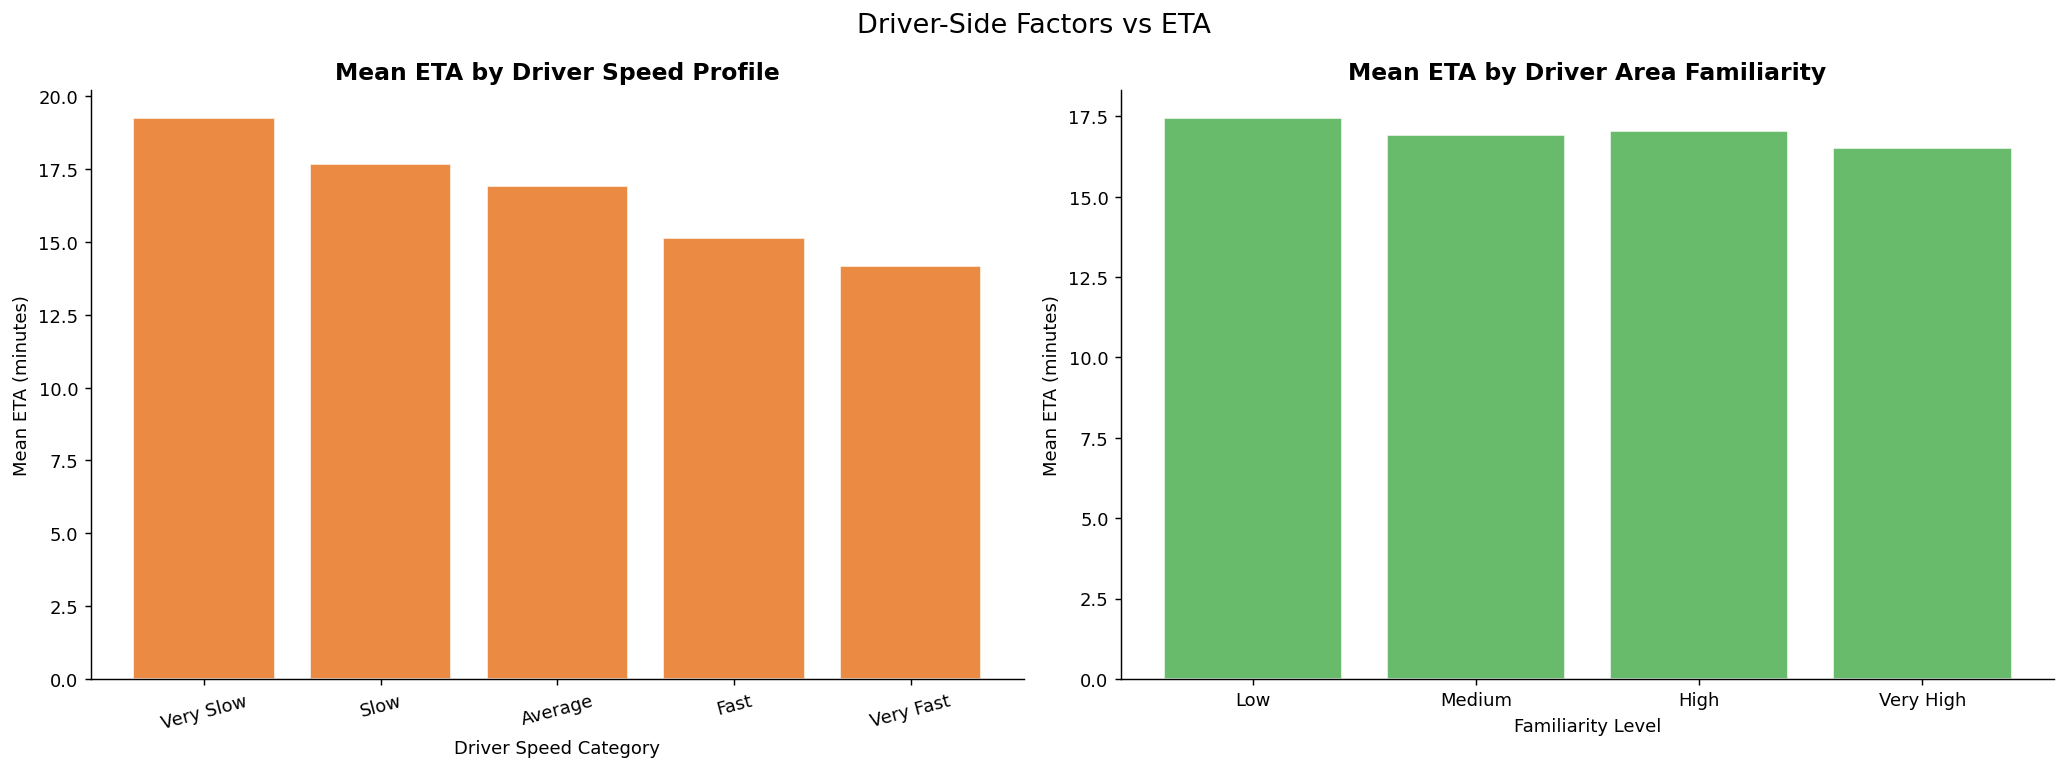

ETA by driver speed:
speed_bucket
Very Slow   19.250
Slow        17.670
Average     16.920
Fast        15.130
Very Fast   14.170
Name: actual_arrival_time_min, dtype: float64

ETA by driver familiarity:
familiarity_bucket
Low         17.440
Medium      16.920
High        17.060
Very High   16.510
Name: actual_arrival_time_min, dtype: float64

ETA when driver is in home zone: 16.33 min
ETA when driver is NOT in home zone: 16.73 min


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Driver-Side Factors vs ETA", fontsize=15)

# Speed factor buckets
assignments_df["speed_bucket"] = pd.cut(
    assignments_df["driver_speed_factor"],
    bins=[0, 0.85, 0.95, 1.05, 1.15, 2],
    labels=["Very Slow","Slow","Average","Fast","Very Fast"]
)
speed_eta = assignments_df.groupby(
    "speed_bucket", observed=True
)["actual_arrival_time_min"].mean()

axes[0].bar(
    speed_eta.index.astype(str), speed_eta.values,
    color="#E87722", edgecolor="white", alpha=0.85
)
axes[0].set_title("Mean ETA by Driver Speed Profile")
axes[0].set_xlabel("Driver Speed Category")
axes[0].set_ylabel("Mean ETA (minutes)")
axes[0].tick_params(axis="x", rotation=15)

# Familiarity buckets
assignments_df["familiarity_bucket"] = pd.cut(
    assignments_df["driver_familiarity_score"],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=["Low","Medium","High","Very High"]
)
fam_eta = assignments_df.groupby(
    "familiarity_bucket", observed=True
)["actual_arrival_time_min"].mean()

axes[1].bar(
    fam_eta.index.astype(str), fam_eta.values,
    color="#4CAF50", edgecolor="white", alpha=0.85
)
axes[1].set_title("Mean ETA by Driver Area Familiarity")
axes[1].set_xlabel("Familiarity Level")
axes[1].set_ylabel("Mean ETA (minutes)")

plt.tight_layout()
plt.savefig("../data/processed/eda_07_driver_factors.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("ETA by driver speed:")
print(speed_eta.round(2))
print("\nETA by driver familiarity:")
print(fam_eta.round(2))

# Same zone vs different zone — familiarity proxy
same_zone_eta = assignments_df.groupby(
    "is_driver_in_home_zone"
)["actual_arrival_time_min"].mean()
print(f"\nETA when driver is in home zone: {same_zone_eta[1]:.2f} min")
print(f"ETA when driver is NOT in home zone: {same_zone_eta[0]:.2f} min")

## Section 7 — Pickup Pin Accuracy

### Question: Does a poorly placed pickup pin actually
### cost meaningful time?

A user who drops their pin imprecisely forces the driver
to search, call, or circle the area — adding real minutes.

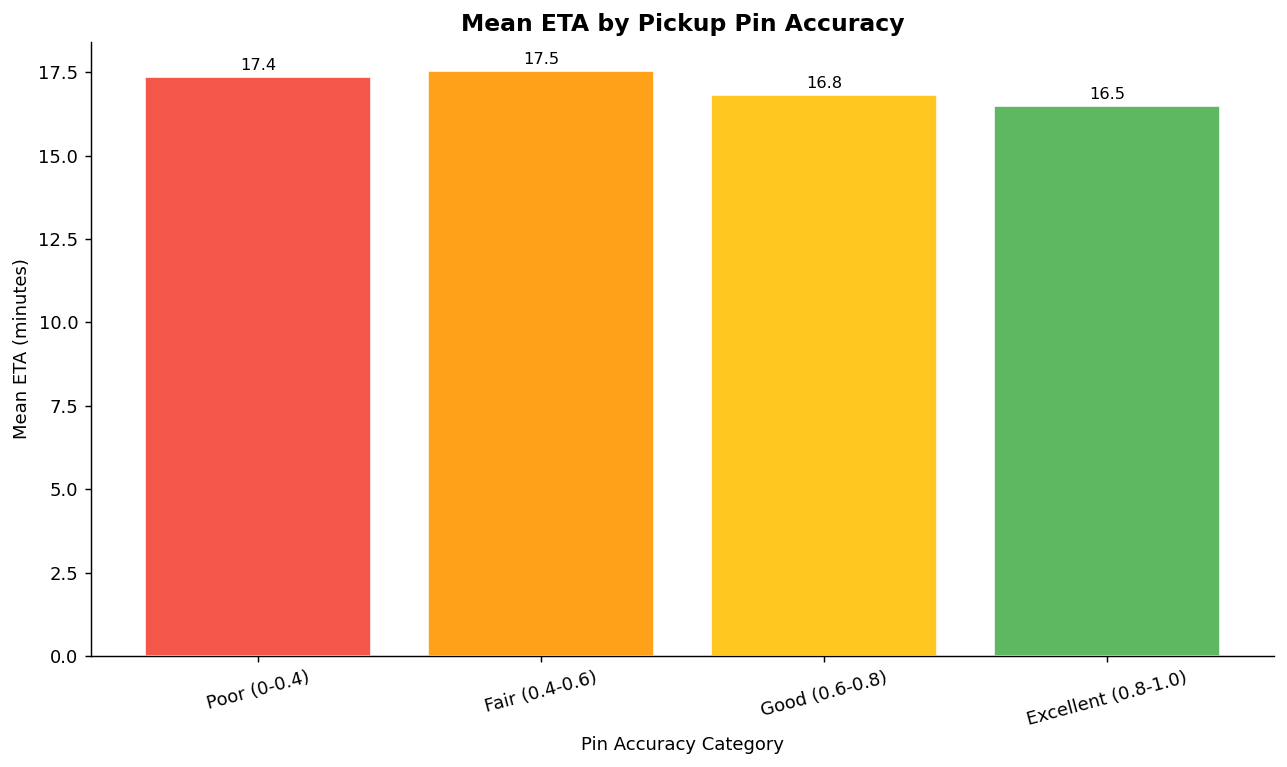

                      mean  count
pin_accuracy_bucket              
Poor (0-0.4)        17.360    626
Fair (0.4-0.6)      17.530   3826
Good (0.6-0.8)      16.810  26813
Excellent (0.8-1.0) 16.490  26420


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

assignments_df["pin_accuracy_bucket"] = pd.cut(
    assignments_df["pickup_pin_accuracy"],
    bins=[0, 0.4, 0.6, 0.8, 1.0],
    labels=["Poor (0-0.4)","Fair (0.4-0.6)",
            "Good (0.6-0.8)","Excellent (0.8-1.0)"]
)

pin_eta = assignments_df.groupby(
    "pin_accuracy_bucket", observed=True
)["actual_arrival_time_min"].agg(["mean", "count"])

colors_pin = ["#F44336","#FF9800","#FFC107","#4CAF50"]
ax.bar(
    pin_eta.index.astype(str), pin_eta["mean"],
    color=colors_pin, edgecolor="white", alpha=0.9
)
ax.set_title("Mean ETA by Pickup Pin Accuracy", fontsize=13)
ax.set_xlabel("Pin Accuracy Category")
ax.set_ylabel("Mean ETA (minutes)")
ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(pin_eta["mean"]):
    ax.text(i, v + 0.2, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_08_pin_accuracy.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(pin_eta.round(2))

## Section 8 — Zone Pair Analysis

### Question: Which specific Bangalore routes have the
### worst average ETAs?

Our data generator encoded specific corridor knowledge
(Whitefield→MG Road is notoriously bad). This section
verifies that knowledge shows up clearly in the data.

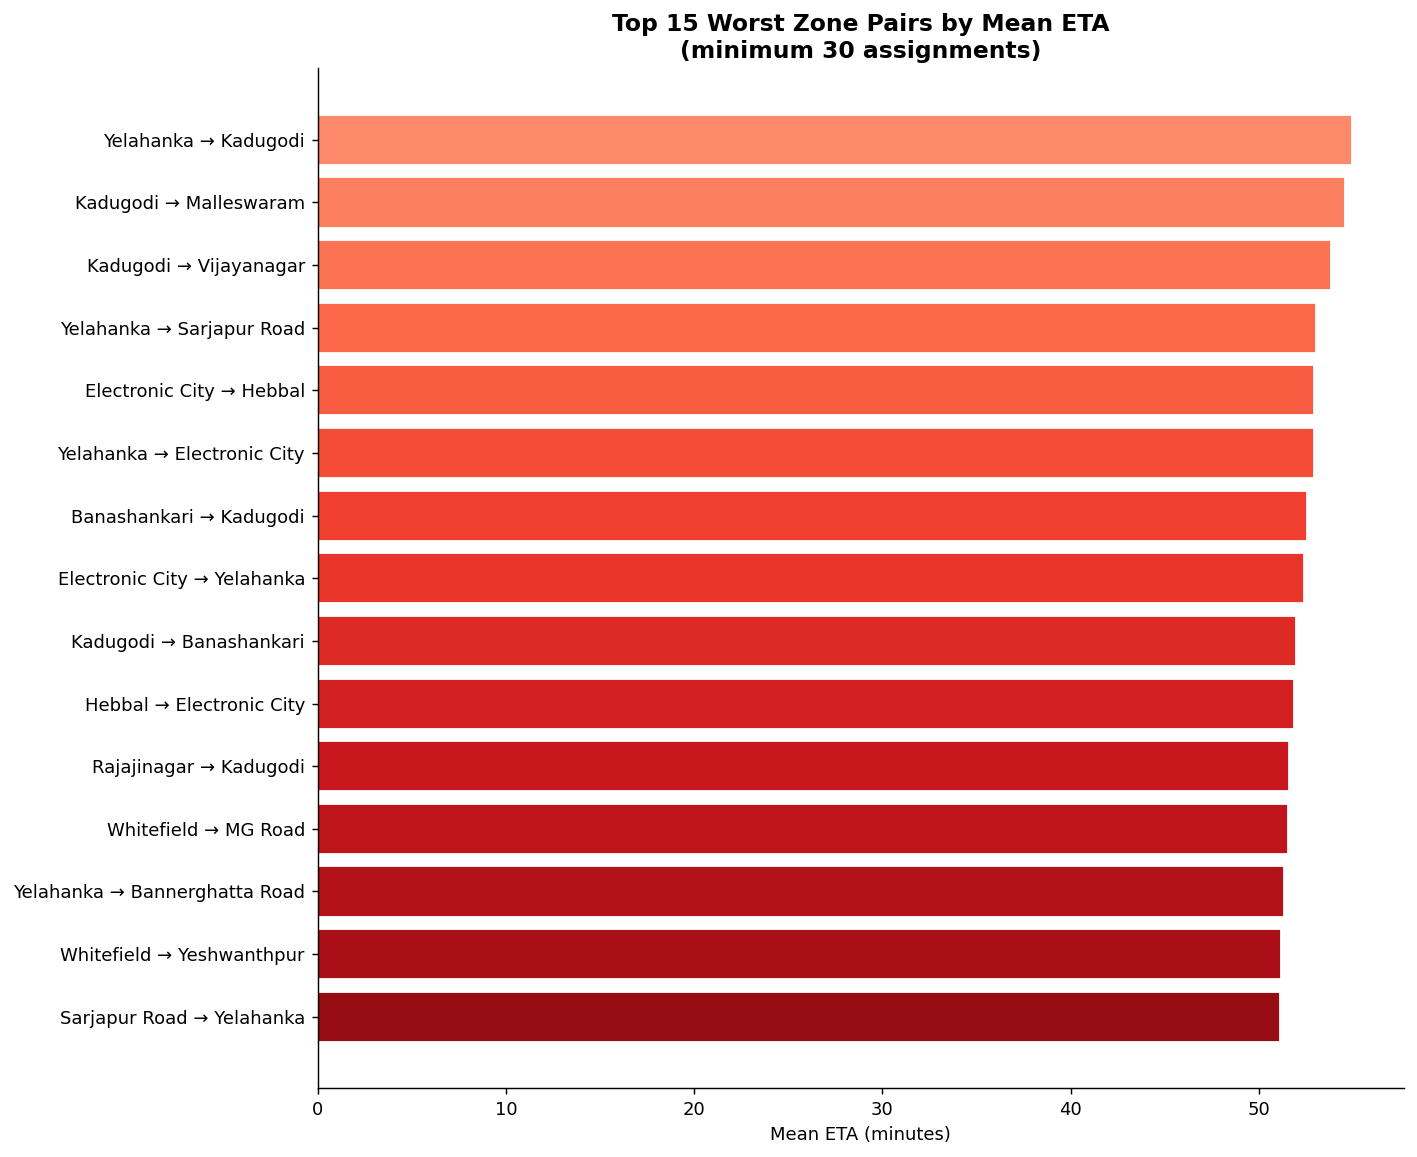

Top 10 worst zone pairs:
                 pair_label   mean  count
       Yelahanka → Kadugodi 54.959     32
     Kadugodi → Malleswaram 54.560     30
     Kadugodi → Vijayanagar 53.837     43
  Yelahanka → Sarjapur Road 53.044     48
   Electronic City → Hebbal 52.950     38
Yelahanka → Electronic City 52.942     43
    Banashankari → Kadugodi 52.544     32
Electronic City → Yelahanka 52.394     32
    Kadugodi → Banashankari 51.957     44
   Hebbal → Electronic City 51.844     45

Best 5 zone pairs (lowest ETA):
                       pair_label  mean  count
                MG Road → MG Road 4.296   1356
          BTM Layout → BTM Layout 4.267   1446
        Koramangala → Koramangala 4.131   1379
Cunningham Road → Cunningham Road 3.985   1377
        Indiranagar → Indiranagar 3.698   1424


In [11]:
zone_pair_eta = assignments_df.groupby(
    ["driver_zone", "pickup_zone"]
)["actual_arrival_time_min"].agg(["mean", "count"]).reset_index()

# Only look at pairs with meaningful sample size
zone_pair_eta = zone_pair_eta[zone_pair_eta["count"] >= 30]
zone_pair_eta = zone_pair_eta.sort_values("mean", ascending=False)

zone_pair_eta["pair_label"] = (
    zone_pair_eta["driver_zone"] + " → " + zone_pair_eta["pickup_zone"]
)

fig, ax = plt.subplots(figsize=(11, 9))
top15 = zone_pair_eta.head(15)

colors_zone = plt.cm.Reds(np.linspace(0.4, 0.9, len(top15)))
ax.barh(top15["pair_label"], top15["mean"],
        color=colors_zone, edgecolor="white")
ax.set_title("Top 15 Worst Zone Pairs by Mean ETA\n(minimum 30 assignments)",
             fontsize=13)
ax.set_xlabel("Mean ETA (minutes)")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/eda_09_zone_pairs.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 worst zone pairs:")
print(top15[["pair_label","mean","count"]].head(10).to_string(index=False))

print("\nBest 5 zone pairs (lowest ETA):")
print(zone_pair_eta[["pair_label","mean","count"]].tail(5).to_string(index=False))

## Section 9 — App ETA Accuracy Check

### Question: How good is the app's CURRENT estimate?
### This is our baseline to beat.

If our model cannot outperform what the app already shows,
we have built nothing of value. This analysis sets the bar.

In [12]:
app_data = assignments_df.dropna(
    subset=["app_shown_eta_min", "actual_arrival_time_min"]
)

app_mae  = (app_data["app_shown_eta_min"] -
            app_data["actual_arrival_time_min"]).abs().mean()
app_rmse = np.sqrt(
    ((app_data["app_shown_eta_min"] -
      app_data["actual_arrival_time_min"])**2).mean()
)
app_mape = (
    (app_data["app_shown_eta_min"] -
     app_data["actual_arrival_time_min"]).abs() /
    app_data["actual_arrival_time_min"]
).mean() * 100

print("=" * 50)
print(" APP'S CURRENT ETA PERFORMANCE (our baseline)")
print("=" * 50)
print(f"  MAE  : {app_mae:.2f} minutes")
print(f"  RMSE : {app_rmse:.2f} minutes")
print(f"  MAPE : {app_mape:.2f}%")
print("=" * 50)
print("\nOur model in Notebook 05 must beat these numbers")
print("to demonstrate real business value.")

 APP'S CURRENT ETA PERFORMANCE (our baseline)
  MAE  : 2.09 minutes
  RMSE : 3.36 minutes
  MAPE : 12.58%

Our model in Notebook 05 must beat these numbers
to demonstrate real business value.


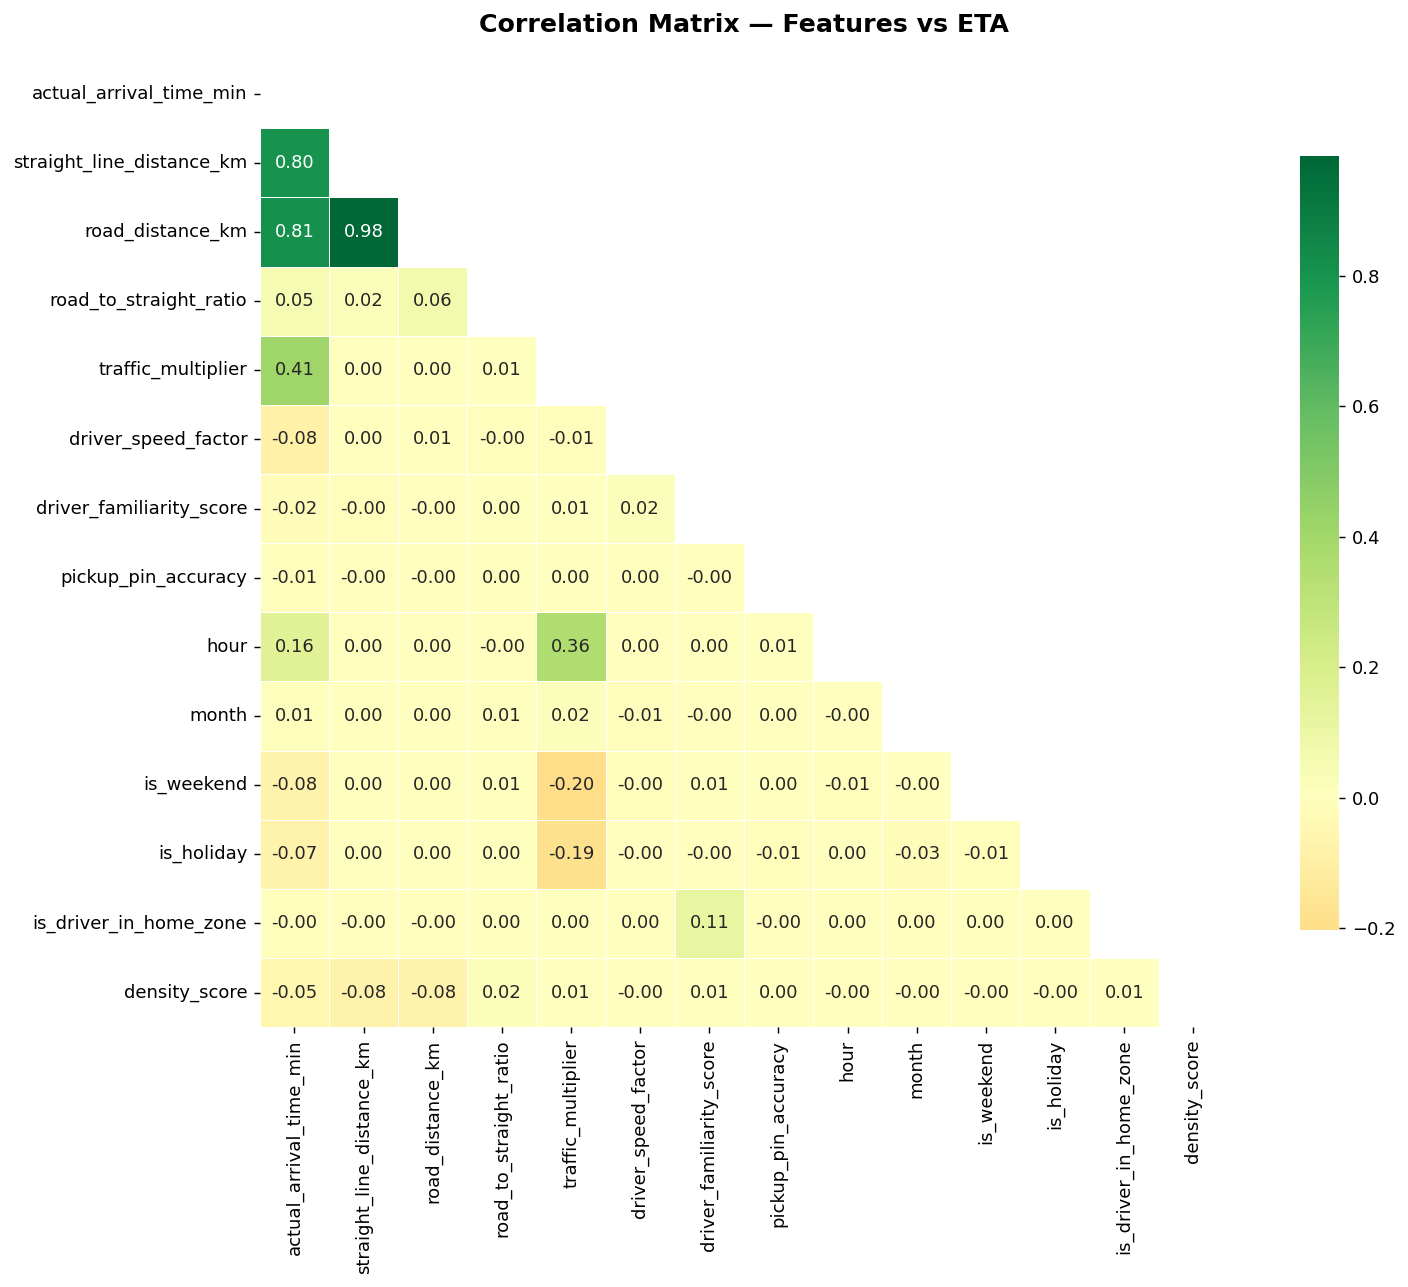

Correlation with actual_arrival_time_min (sorted):
road_distance_km             0.811
straight_line_distance_km    0.800
traffic_multiplier           0.411
hour                         0.162
road_to_straight_ratio       0.048
month                        0.011
is_driver_in_home_zone      -0.004
pickup_pin_accuracy         -0.013
driver_familiarity_score    -0.017
density_score               -0.052
is_holiday                  -0.072
is_weekend                  -0.081
driver_speed_factor         -0.084
Name: actual_arrival_time_min, dtype: float64


In [13]:
corr_cols = [
    "actual_arrival_time_min", "straight_line_distance_km",
    "road_distance_km", "road_to_straight_ratio",
    "traffic_multiplier", "driver_speed_factor",
    "driver_familiarity_score", "pickup_pin_accuracy",
    "hour", "month", "is_weekend", "is_holiday",
    "is_driver_in_home_zone", "density_score"
]
corr_cols = [c for c in corr_cols if c in assignments_df.columns]

corr_df = assignments_df[corr_cols].copy()
corr_df["is_weekend"] = corr_df["is_weekend"].astype(int)
corr_df["is_holiday"] = corr_df["is_holiday"].astype(int)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Matrix — Features vs ETA", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eda_10_correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Correlation with actual_arrival_time_min (sorted):")
eta_corr = corr_matrix["actual_arrival_time_min"].drop(
    "actual_arrival_time_min"
).sort_values(ascending=False)
print(eta_corr.round(4))

## EDA Summary — Key Findings for Modeling

### Feature Strength Summary (from Correlation Analysis)
| Feature | Correlation | Interpretation |
|---|---|---|
| road_distance_km | **+0.811** | Strongest predictor — distance IS ETA to a large degree |
| straight_line_distance_km | **+0.800** | Nearly identical to road distance — both capture same signal |
| traffic_multiplier | **+0.411** | Second strongest — severe traffic causes 9x time increase |
| hour | **+0.162** | Peak hours indirectly increase ETA via traffic |
| road_to_straight_ratio | **+0.048** | Route complexity adds time but weakly linear |
| month | **+0.011** | Negligible linear signal |
| is_driver_in_home_zone | **-0.004** | Near zero — familiarity has minimal linear impact |
| pickup_pin_accuracy | **-0.013** | Negative — poor accuracy slightly increases ETA |
| driver_familiarity_score | **-0.017** | Negative — more familiar = slightly shorter ETA |
| density_score | **-0.052** | Negative — denser zones have shorter ETAs (more nearby drivers) |
| is_holiday | **-0.072** | Negative — holidays have LESS traffic = faster arrival |
| is_weekend | **-0.081** | Negative — weekends have less peak congestion = faster |
| driver_speed_factor | **-0.084** | Negative — higher speed factor = shorter arrival time |

---

### App Baseline We Must Beat
| Metric | App Current Performance |
|---|---|
| MAE | **2.09 minutes** |
| RMSE | **3.36 minutes** |
| MAPE | **12.58%** |

This is a genuinely high bar. Our model must beat all
three numbers to demonstrate real business value.

---

### Key Observations

**1. Distance dominates with 0.811 correlation — but this is both
good news and a warning.**

Good news: there is a real, strong, learnable signal here.
This project has more predictable structure than either surge
pricing (max 0.31) or cancellation prediction (max 0.181).

Warning: `road_distance_km` (0.811) and `straight_line_distance_km`
(0.800) are nearly identical in predictive power and are
mathematically derived from each other. Using both in a model
creates **multicollinearity** — the model gets confused because
two features are telling it the same thing twice with slightly
different numbers. We will keep only `road_distance_km` in the
final feature matrix and drop `straight_line_distance_km` to
avoid this problem.

**2. Traffic is powerful but non-linear — the most important
modeling insight of this entire EDA.**

Correlation of 0.411 understates the true effect dramatically.
The controlled comparison showed:
- Low traffic (same 3-4km distance): 4.01 minutes
- Normal traffic (same distance): 7.19 minutes
- Severe traffic (same distance): 36.61 minutes

A 9x difference on the EXACT SAME distance. This jump from
normal to severe traffic is completely non-linear — no straight
line can represent "normal is 7 minutes but severe is 37
minutes." This is the single strongest argument for tree-based
models (XGBoost, LightGBM, Random Forest) over linear models
in this project. Linear regression will approximate this with
one slope and miss the cliff-edge behavior of severe traffic.

**3. Direction of correlations reveals important domain knowledge.**

All behavioral and driver-side features show NEGATIVE correlation:
- `driver_speed_factor: -0.084` — faster driver = shorter time ✅
- `driver_familiarity_score: -0.017` — more familiar = shorter ✅
- `is_weekend: -0.081` — weekend = less traffic = shorter ✅
- `is_holiday: -0.072` — holiday = much less traffic = shorter ✅
- `pickup_pin_accuracy: -0.013` — better pin = shorter ✅

Every negative correlation here is pointing in the correct
direction. Faster drivers arrive faster. Familiar drivers
arrive faster. Weekends and holidays have less congestion.
Better pin placement reduces search time. Our data generator
encoded real-world logic and the correlations confirm it worked
correctly.

**4. Weather has a moderate but meaningful impact (48.8% increase
from Clear to Storm).**

Storm mean: 23.09 min vs Clear mean: 15.52 min — 7.57 minutes
extra. More importantly, median jumps from 6.3 (Clear) to
13.4 (Storm) — a 112% increase. The median tells a stronger
story here because it is not influenced by long-distance
assignments that exist in both categories. Weather is a
real signal worth including in the model.

**5. Short-distance assignments are the hardest to predict.**

The 0-1km bucket has standard deviation of 2.33 minutes on a
mean of 2.32 minutes — coefficient of variation of 100%.
A 0.5km ride can take anywhere from 1 to 8 minutes. Long
distance assignments (10+ km) have CV of only 43% —
proportionally much more predictable. Our model will be
less accurate for short assignments and this is expected.
We will document this in Notebook 06 evaluation.

**6. The app baseline (MAE 2.09 min) is a high bar but beatable.**

The app uses a simple formula-based estimate. Our ML model
will capture the non-linear traffic interaction and the
combined effect of multiple features simultaneously. The
9x traffic jump and weather compounding effects are exactly
the kind of patterns a gradient boosting model discovers
that a formula misses.

---

### Critical Finding: Multicollinearity Warning

`road_distance_km` and `straight_line_distance_km` both
correlate at 0.81 with ETA. They are derived from each other
(road = straight × ratio). Keeping both in a model is like
telling the model the same thing twice — it wastes a feature
slot, inflates feature importance scores artificially, and
confuses linear models.

**Decision: drop `straight_line_distance_km` from features.
Keep `road_distance_km` only.**

We keep `road_to_straight_ratio` separately since it captures
route complexity — the SHAPE of the route — which is different
information from the raw distance.

---

### Implications for Feature Engineering

**Must do:**
- Drop `straight_line_distance_km` — multicollinear with road distance
- Cyclical encoding for `hour` and `month` — same as previous projects
- Target encoding for `driver_zone` and `pickup_zone` — encode by average ETA
- One-hot encode `vehicle_type`, `day_of_week`, `weather_condition`

**New engineered features to create:**
- `traffic_distance_interaction` — traffic_multiplier × road_distance_km.
  Directly encodes the 9x non-linear effect we found. Helps linear
  models approximate what trees discover automatically.
- `expected_travel_time_min` — road_distance / (base_speed × speed_factor) × 60.
  Physics-based baseline estimate — what the time SHOULD be with
  no traffic. Residual from this estimate captures unexplained variance.
- `is_peak_hour` — binary flag for hours 8-10am and 5-8pm, directly
  encoding the hourly pattern EDA revealed.
- `is_rain` — binary flag for Light Rain / Heavy Rain / Storm, since
  any rain meaningfully increases ETA.
- `zone_pair_avg_eta` — target encode each driver_zone + pickup_zone
  combination by its average ETA. Captures corridor-specific patterns.

**Encoding for categorical columns:**
- `weather_condition` — ordinal (Clear=0 to Storm=5), same as before
- `vehicle_type` and `day_of_week` — one-hot encoding

---

### Implications for Model Selection

**Tree-based models (XGBoost, LightGBM, Random Forest) are
strongly preferred here over linear models for one reason:**
the 9x traffic non-linearity. No linear regression can capture
"traffic multiplier of 2.0+ causes a 36-minute arrival versus
7 minutes at normal traffic on the same distance." Trees
naturally discover this cliff-edge pattern through splits.

However — unlike cancellation prediction where linear models
were clearly outclassed — linear models here MIGHT perform
decently because the overall distance correlation (0.811) is
so strong. A linear model saying "ETA ≈ distance × constant"
will be approximately right most of the time. The question
for Notebook 05 is: how much better can tree models do by
capturing the traffic interaction on top of that strong
distance baseline?

---

### The Baseline We Are Beating:
App MAE = **2.09 min** | App RMSE = **3.36 min** | App MAPE = **12.58%**
Every model in Notebook 05 will be judged against these numbers first,
then against each other.